# CHURN ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

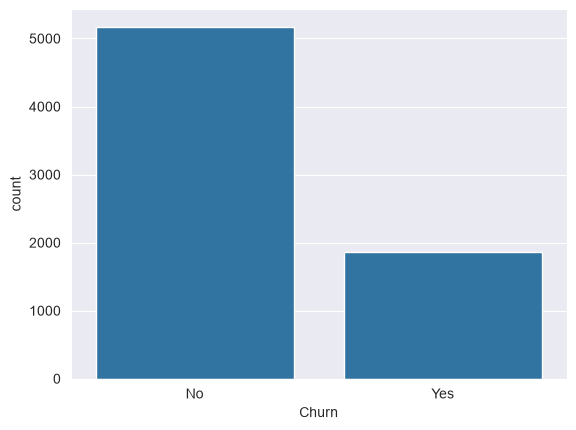

In [7]:
#Is dataset balacnced?
sns.countplot(x="Churn", data=df)
plt.show()

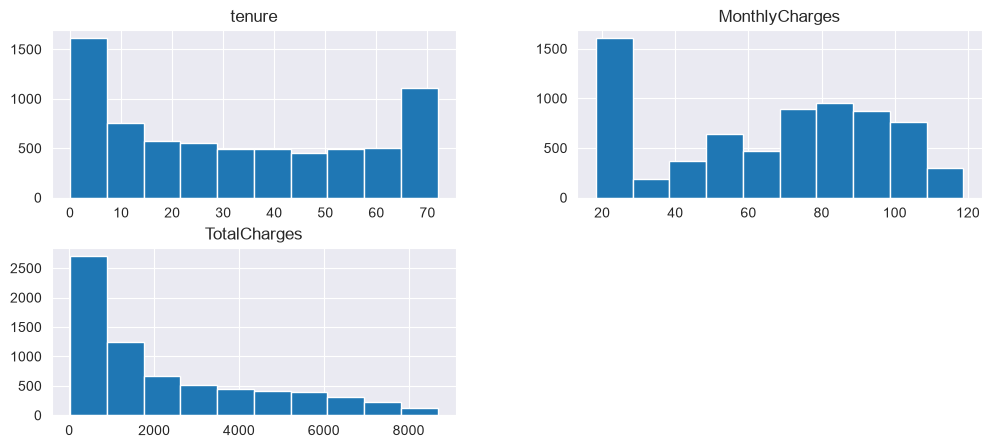

In [9]:
#Numerical Distribution
df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].hist(figsize=(12, 5))
plt.show()

In [ ]:
#Churn vs Numerical Features

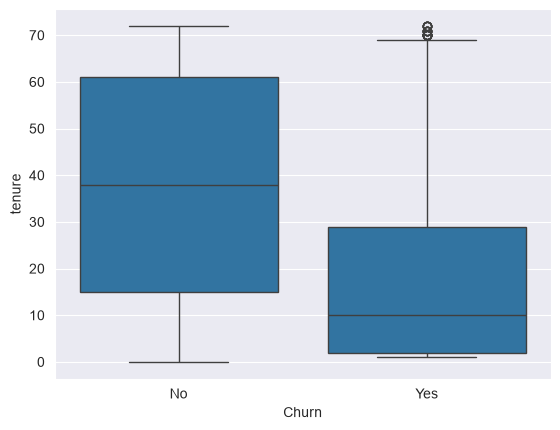

In [10]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

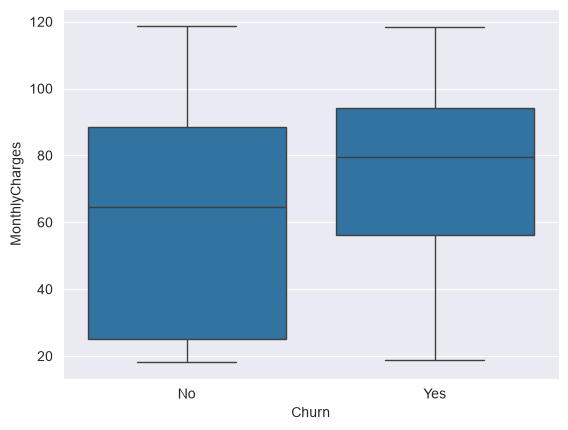

In [11]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

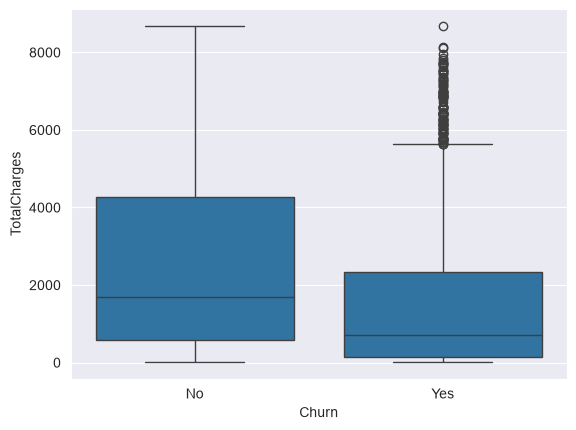

In [12]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.show()

In [ ]:
#Categorical Analysis

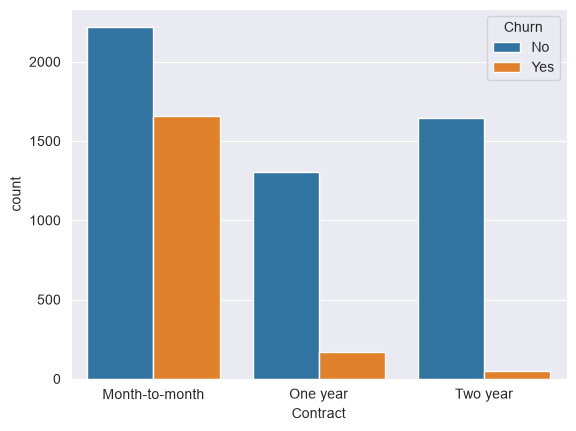

In [13]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.show()

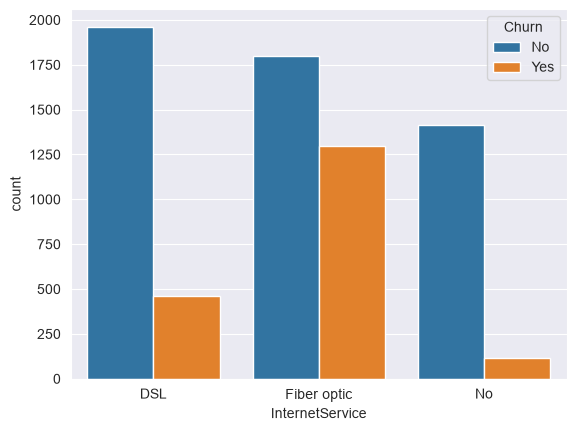

In [14]:
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.show()

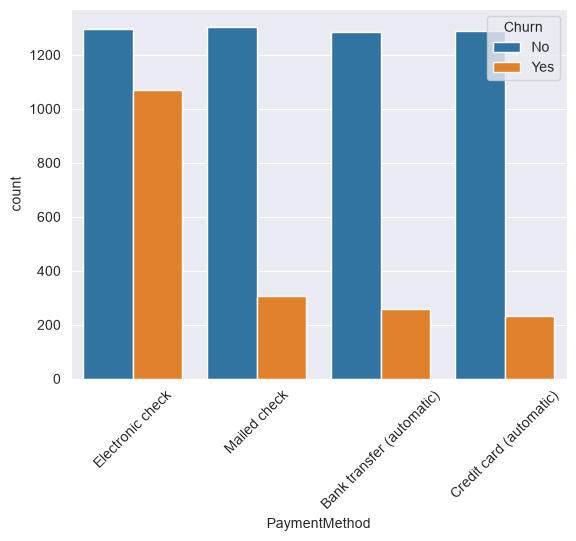

In [15]:
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.show()

In [6]:
df['Churn'] = df['Churn'].map({
    "No":0,
    "Yes":1
})

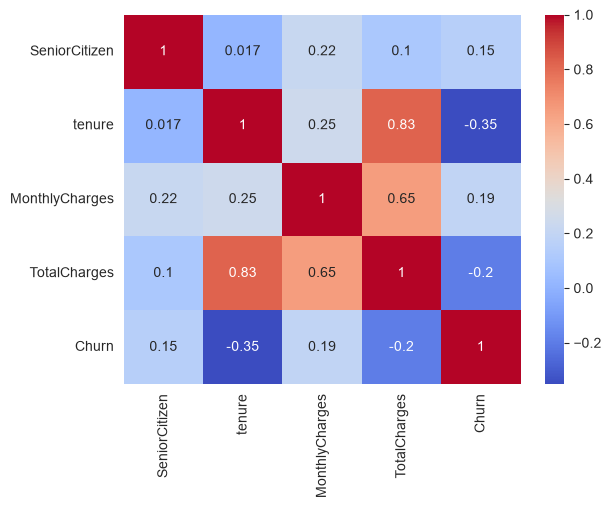

In [17]:
#Correlation
numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [18]:
print(df["PaperlessBilling"].unique())

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


In [7]:
binary_cols = [
    "Partner",
    "Dependents",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].astype(str).map({
        "No": 0,
        "Yes": 1
    })

print(df[binary_cols].head())

   Partner  Dependents  PaperlessBilling
0        1           0                 1
1        0           0                 0
2        0           0                 1
3        0           0                 0
4        0           0                 1


In [20]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
df["Contract"].head()

0    Month-to-month
1          One year
2    Month-to-month
3          One year
4    Month-to-month
Name: Contract, dtype: str

In [8]:
X = df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Partner",
    "Dependents",
    "PaperlessBilling"
]]

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1:",f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7494677075940384
Precision: 0.5239234449760766
Recall: 0.5871313672922251
F1: 0.5537294563843237
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1036
           1       0.52      0.59      0.55       373

    accuracy                           0.75      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.76      0.75      0.75      1409

[[837 199]
 [154 219]]


ROC-AUC Score: 0.7901290796733157


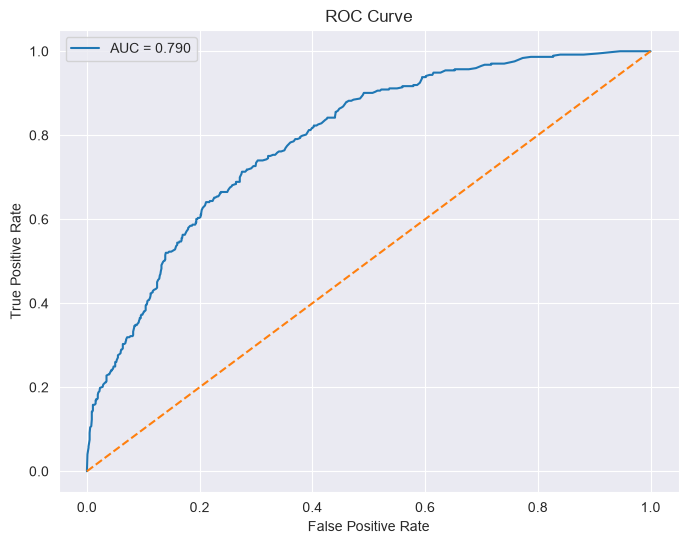

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [9]:
from sklearn.linear_model import LogisticRegression
model_1 = LogisticRegression(max_iter=1000)
model_1.fit(X_train, y_train)
y_pred = model_1.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1:",f1_score(y_test, y_pred))

Accuracy: 0.794180269694819
Precision: 0.6456140350877193
Recall: 0.4932975871313673
F1: 0.5592705167173252


In [10]:
from xgboost import XGBClassifier

model_2 = XGBClassifier()
model_2.fit(X_train, y_train)

y_pred = model_2.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1:",f1_score(y_test, y_pred))

Accuracy: 0.7778566359119943
Precision: 0.5993377483443708
Recall: 0.48525469168900803
F1: 0.5362962962962963


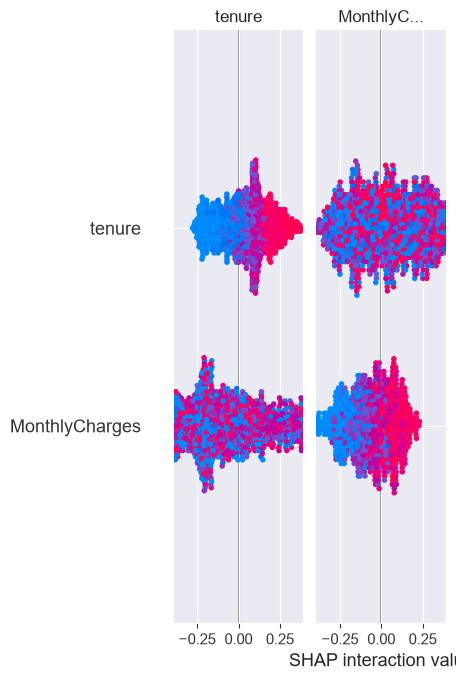

In [11]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)